# UK music output share versus population share

## tl;dr

This experiment reframes the existing per-capita question as a share comparison.
An output quotient of `1.0×` means that an FUA's share of selected music output
equals its share of the population; `2.0×` means twice the proportional output.

Using the reviewed extended mapping of the frozen top 1000 catalogue:

- **Brighton and Hove** has the largest selected-band quotient
  among FUAs represented by at least two bands: **1.77×**
  from 15 selected bands.
- **Sheffield** has the largest follower-share quotient
  in that multi-band group: **2.72×**.
- **London** represents 23.6% of the population across
  the 83-FUA universe, 29.9% of the selected bands and
  53.9% of their followers.
- One-band results remain fragile: **Crawley**
  reaches **3.59×** on the
  follower quotient through one selected act.

The chart is descriptive, not a model of how music output should scale with city
size. Its rankings are mathematically identical to the corresponding per-capita
rankings when the same universes and denominators are used.

## Context & Methods

The selected music universe is the frozen popularity-first top 1000 of
eligible UK groups ranked by captured Spotify monthly listeners. Origins are
assigned to 2021 OECD/EU Functional Urban Areas (FUAs). The main view includes
both strict and reviewed-extended assignments because this maximizes coverage;
strict-only coverage is retained as a sensitivity check.

For output measure $M$ and population $P$, the quotient is:

$$
Q_i = \frac{M_i / M_{UK}}{P_i / P_{UK}}
    = \frac{M_i/P_i}{M_{UK}/P_{UK}}.
$$

The experiment calculates three versions:

1. **Band representation:** share of the selected top-1000 bands.
2. **Follower impact:** share of followers across those selected bands.
3. **Monthly-listener impact:** share of the frozen monthly-listener total.

The primary chart puts population share on the x-axis and follower share on the
y-axis. Its bubble area encodes selected-band count. Points above the parity
line have a follower output quotient greater than `1.0×`. A secondary chart
retains band share on the y-axis so breadth remains visible.

### Key Assumptions

- The population universe contains all 83 UK FUAs in the frozen OECD extract,
  including places with no selected bands.
- The music denominators contain all 1000 selected bands and their full
  audience totals, including unmapped bands. Mapped shares therefore sum to
  less than 100% rather than being rescaled upward.
- Followers and monthly listeners are summed artist-level counts with unknown
  audience overlap; neither is a unique-person total.
- Current 2021 population is compared with bands formed across many decades.
- The top-1000 cutoff and Spotify-based candidate frame are measurement
  choices, not a census of British music.

## Data

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv").exists()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Could not locate the uk-music-cities repository root")

import sys
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from python_uk_bands.output_share import (
    build_output_share_metrics,
    plot_band_share_vs_population_share,
    plot_follower_share_vs_population_share,
)

SNAPSHOT_ID = "20260718T204522Z"
TOP_N = 1000
BANDS_PATH = ROOT / "data/processed/popularity_first_top1000_20260718T204522Z_bands.csv"
MAPPING_AUDIT_PATH = ROOT / "data/interim/popularity_first_top1000_20260718T204522Z_fua_mapping_audit.csv"
POPULATION_PATH = ROOT / "data/processed/uk_fua_population_2021_20260718T201304Z.csv"
CHART_OUTPUT_DIR = ROOT / "artifacts/experiments/top1000_output_share_vs_population/20260718T204522Z"
OUTPUT_TABLE_PATH = ROOT / "artifacts/experiments/top1000_output_share_vs_population/20260718T204522Z/fua_output_shares_extended.csv"

bands = pd.read_csv(BANDS_PATH, keep_default_na=False)
mapping_audit = pd.read_csv(MAPPING_AUDIT_PATH, keep_default_na=False)
population = pd.read_csv(POPULATION_PATH, keep_default_na=False)

strict_shares, strict_coverage = build_output_share_metrics(
    bands,
    mapping_audit,
    population,
    included_tiers={"strict"},
)
shares, coverage = build_output_share_metrics(
    bands,
    mapping_audit,
    population,
    included_tiers={"strict", "reviewed_extended"},
)

CHART_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
shares.to_csv(OUTPUT_TABLE_PATH, index=False)

coverage_table = pd.DataFrame(
    [
        {
            "Mapping": "Strict",
            "Mapped bands": strict_coverage["mapped_bands"],
            "Band share": strict_coverage["mapped_band_share"],
            "Follower share": strict_coverage["mapped_follower_share"],
            "Monthly-listener share": strict_coverage["mapped_monthly_listener_share"],
            "Represented FUAs": strict_coverage["mapped_fuas"],
        },
        {
            "Mapping": "Strict + reviewed extended",
            "Mapped bands": coverage["mapped_bands"],
            "Band share": coverage["mapped_band_share"],
            "Follower share": coverage["mapped_follower_share"],
            "Monthly-listener share": coverage["mapped_monthly_listener_share"],
            "Represented FUAs": coverage["mapped_fuas"],
        },
    ]
)
display(
    coverage_table.style.hide(axis="index").format(
        {
            "Band share": "{:.1%}",
            "Follower share": "{:.1%}",
            "Monthly-listener share": "{:.1%}",
        }
    )
)
display(Markdown(f"Saved the full 83-FUA table to `{OUTPUT_TABLE_PATH.relative_to(ROOT)}`."))

Mapping,Mapped bands,Band share,Follower share,Monthly-listener share,Represented FUAs
Strict,656,65.6%,92.1%,90.1%,61
Strict + reviewed extended,660,66.0%,92.4%,90.5%,61


Saved the full 83-FUA table to `artifacts/experiments/top1000_output_share_vs_population/20260718T204522Z/fua_output_shares_extended.csv`.

The primary reviewed-extended view improves output coverage while
retaining the full catalogue denominator. The stricter view is useful for
checking whether reviewed boundary assignments change the interpretation.

## Results

### Follower-share chart

Follower share supplies the vertical position and selected-band count supplies
bubble area. Marker treatment distinguishes one-band cases from FUAs with at
least two selected bands. Zero-output FUAs remain in the population denominator
and exported table but cannot be positioned on a log y-axis.

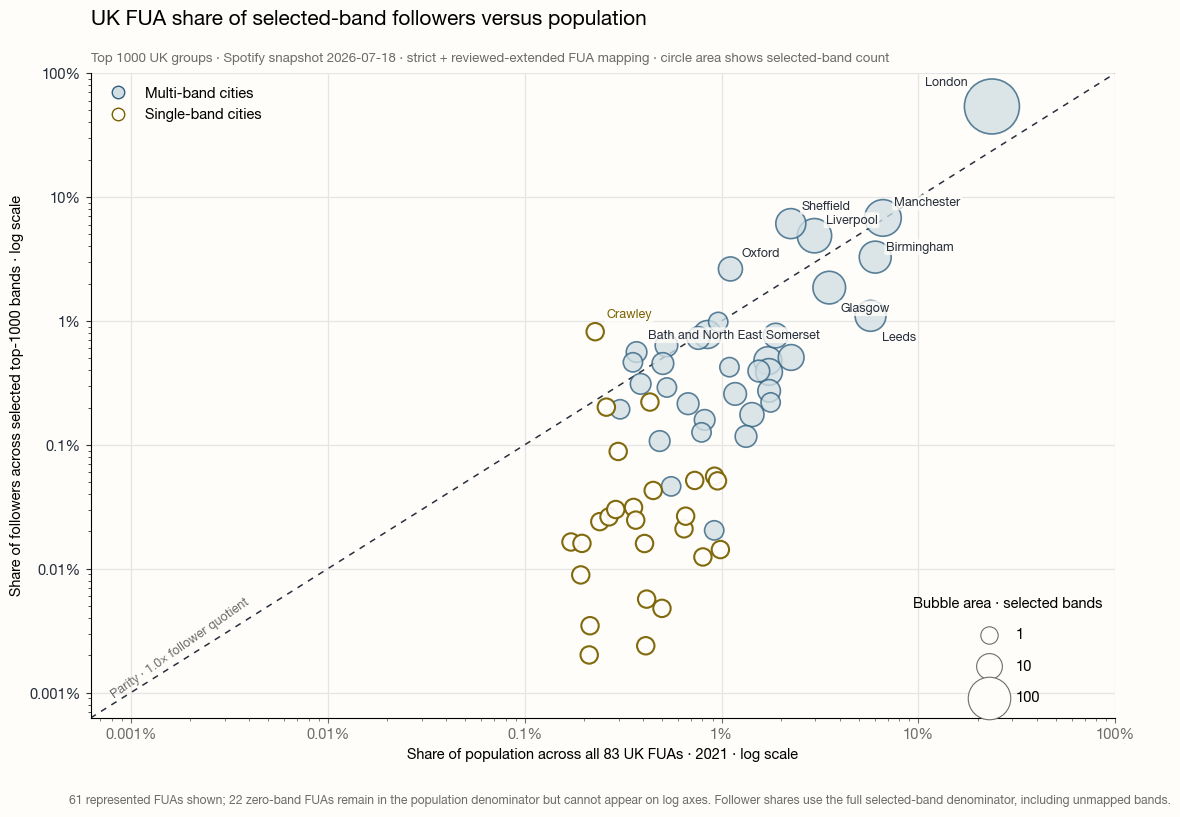

Exported to `artifacts/experiments/top1000_output_share_vs_population/20260718T204522Z/chart_01_follower_share_vs_population_share.png`.

In [2]:
chart_path = plot_follower_share_vs_population_share(
    shares,
    snapshot_date="2026-07-18",
    selected_count=TOP_N,
    mapping_label="strict + reviewed-extended FUA mapping",
    output_dir=CHART_OUTPUT_DIR,
)
display(Markdown(f"Exported to `{chart_path.relative_to(ROOT)}`."))

The vertical position now measures audience impact directly. A
point above the line contributes a larger follower share than its population
share, while bubble area shows how many selected bands contribute to that
result.

### Exact quotients and concentration

In [3]:
represented = (
    shares.loc[shares["band_count"].gt(0)]
    .sort_values(
        ["follower_output_quotient", "band_output_quotient"],
        ascending=False,
    )
    .head(20)
    [
        [
            "study_city_label",
            "band_count",
            "population_share",
            "band_share",
            "band_output_quotient",
            "follower_share",
            "follower_output_quotient",
            "largest_band_by_followers",
            "largest_band_follower_share",
        ]
    ]
    .rename(
        columns={
            "study_city_label": "FUA",
            "band_count": "Bands",
            "population_share": "Population share",
            "band_share": "Band share",
            "band_output_quotient": "Band quotient",
            "follower_share": "Follower share",
            "follower_output_quotient": "Follower quotient",
            "largest_band_by_followers": "Largest band",
            "largest_band_follower_share": "Largest-band share",
        }
    )
)
display(
    represented.style.hide(axis="index").format(
        {
            "Population share": "{:.2%}",
            "Band share": "{:.2%}",
            "Band quotient": "{:.2f}×",
            "Follower share": "{:.2%}",
            "Follower quotient": "{:.2f}×",
            "Largest-band share": "{:.1%}",
        }
    )
)

FUA,Bands,Population share,Band share,Band quotient,Follower share,Follower quotient,Largest band,Largest-band share
Crawley,1,0.23%,0.10%,0.44×,0.82%,3.59×,The Cure,100.0%
Sheffield,21,2.25%,2.10%,0.93×,6.11%,2.72×,Arctic Monkeys,62.7%
Oxford,7,1.11%,0.70%,0.63×,2.63%,2.37×,Radiohead,69.1%
London,299,23.61%,29.90%,1.27×,53.89%,2.28×,Coldplay,13.1%
Liverpool,39,2.96%,3.90%,1.32×,4.88%,1.65×,The Beatles,72.6%
Bath and North East Somerset,3,0.37%,0.30%,0.81×,0.56%,1.51×,Tears For Fears,89.6%
Hastings,2,0.35%,0.20%,0.56×,0.46%,1.31×,Keane,99.4%
Guildford,5,0.53%,0.50%,0.95×,0.63%,1.21×,Genesis,68.2%
Manchester,52,6.60%,5.20%,0.79×,6.79%,1.03×,Oasis,22.5%
Exeter,2,0.96%,0.20%,0.21×,0.98%,1.02×,Muse,99.7%


### Band-representation companion

The companion chart returns to selected-band share on the y-axis. It measures
breadth rather than audience impact. One-band FUAs necessarily align at
`1 / TOP_N`; this discrete row is a property of the count metric, not a plotting
error.

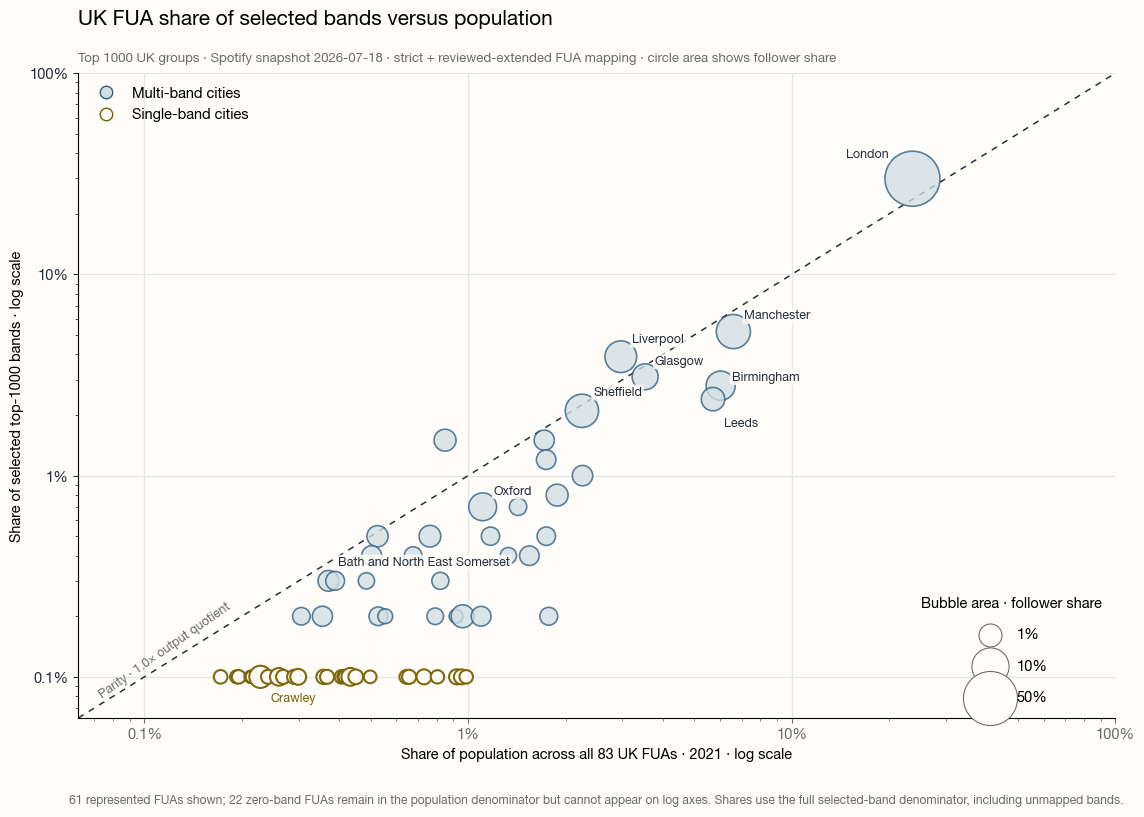

Exported to `artifacts/experiments/top1000_output_share_vs_population/20260718T204522Z/chart_02_band_share_vs_population_share.png`.

In [4]:
band_chart_path = plot_band_share_vs_population_share(
    shares,
    snapshot_date="2026-07-18",
    selected_count=TOP_N,
    mapping_label="strict + reviewed-extended FUA mapping",
    output_dir=CHART_OUTPUT_DIR,
    filename="chart_02_band_share_vs_population_share.png",
)
display(Markdown(f"Exported to `{band_chart_path.relative_to(ROOT)}`."))

### Calculation checks

In [5]:
assert len(shares) == coverage["population_fuas"] == 83
assert coverage["mapped_bands"] == int(shares["band_count"].sum())
assert abs(shares["band_share"].sum() - coverage["mapped_band_share"]) < 1e-12
assert abs(shares["follower_share"].sum() - coverage["mapped_follower_share"]) < 1e-12

national_band_rate = TOP_N / shares["population"].sum()
relative_per_capita_rate = (
    shares["band_count"] / shares["population"] / national_band_rate
)
assert (
    shares["band_output_quotient"] - relative_per_capita_rate
).abs().max() < 1e-12

national_follower_rate = bands["followers"].sum() / shares["population"].sum()
relative_follower_rate = (
    shares["followers_total"] / shares["population"] / national_follower_rate
)
assert (
    shares["follower_output_quotient"] - relative_follower_rate
).abs().max() < 1e-12

assert shares.loc[shares["band_count"].eq(0), "band_share"].eq(0).all()
assert shares.loc[shares["band_count"].eq(0), "band_output_quotient"].eq(0).all()
assert coverage["mapped_band_share"] < 1
assert coverage["mapped_follower_share"] < 1

print(
    "Checks passed: 83-FUA population denominator, full-catalogue output "
    "denominators, zero-output retention, and share/per-capita identity."
)

Checks passed: 83-FUA population denominator, full-catalogue output denominators, zero-output retention, and share/per-capita identity.


## Takeaways

1. **The share framing works.** It makes the expected-output
   comparison explicit: the diagonal is the national-average per-capita rate.
2. **Breadth and audience impact differ.** Brighton and Hove
   leads the multi-band band-count quotient at
   1.77×, while
   Sheffield leads the corresponding follower quotient
   at 2.72×.
3. **Large cities are not automatically penalized.** London has
   1.27× its population-proportional share of
   selected bands and 2.28× its proportional
   follower share.
4. **Small cells still dominate some quotients.** One-band and low-count FUAs
   should remain visible but explicitly marked; the largest-band share is an
   essential concentration guardrail.
5. **This is a presentation improvement, not a new causal estimator.** A later
   log-log or count model should test whether output scales linearly with
   population rather than assuming the parity line is the correct expectation.

### Status

**Share with caveats.** The calculations are internally reproducible and the
chart honestly represents the frozen data, but the catalogue, origin mapping,
current-versus-historical time mismatch and superstar concentration prevent a
definitive ranking of UK music cities.